**Introdução à Clusterização de Séries Temporais**

Este notebook tem como objetivo aprender sobre a clusterização de séries temporais, especialmente utilizando Self-Organizing Maps.
Me baseei no Notebook "[Introduction to Time Series Clustering](https://www.kaggle.com/code/izzettunc/introduction-to-time-series-clustering)".

## O que é clusterização

A clusterização é um tipo de aprendizado não supervisionado cuja ideia principal é encontrar similaridades entre diferentes pontos de dados e unificá-los sobre um mesmo grupo de de maneira que os elementos dentro daquele mesmo grupo sejam mais parecidos entre si do que com os elementos de outros grupos. É muito utilizado em diversas áreas, como mineração de dados, bioinformática, reconhecimento de padrões, etc.

## O que são séries temporais?

Séries temporais são sequências de dados de medições realizadas em uma frequência regular. Elas são indexadas em ordem cronológica, o que permite analisar a evolução dos dados ao longo do tempo.

## Análise Inicial

Farei uso dos dados do [GAIA (Generic AIOps Atlas)](https://github.com/CloudWise-OpenSource/GAIA-DataSet). Estes dados contêm séries temporais de métricas de sistemas de TI, que serão utilizadas para realizar a clusterização e análise de padrões ao longo do tempo.

In [41]:
# Importação de bibliotecas
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pré-processamento
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# Algoritmos
from minisom import MiniSom
# from tslearn.barycenters import dtw_barycenter_averaging
# from tslearn.clustering import TimeSeriesKMeans
# from sklearn.cluster import KMeans
# from sklearn.decomposition import PCA

In [42]:
# path do dataset de métricas
metric_path = "/home/joaoz/estudos/mestrado/datasets/GAIA-DataSet/MicroSS/metric"
# Caminhos para os arquivos CSV de métricas de CPU do serviço de banco de dados (Total e Normalizado)
# O total não considera os cores individualmente, enquanto o normalizado ajusta os valores para refletir a utilização relativa.
# Isso significa que o total pode ultrapasar 100% se houver múltiplos núcleos sendo utilizados simultaneamente.

db_service_cpu_total_pct = f"{metric_path}/dbservice1_0.0.0.4_docker_cpu_total_pct_2021-07-01_2021-07-15.csv"
# db_service_cpu_total_pct = f"{metric_path}/dbservice1_0.0.0.4_docker_cpu_total_pct_2021-07-15_2021-07-31.csv"
# db_service_cpu_total_pct = f"{metric_path}/dbservice1_0.0.0.4_docker_cpu_total_pct_2021-08-01_2021-08-31.csv"


db_service_cpu_total_norm = f"{metric_path}/dbservice1_0.0.0.4_docker_cpu_total_norm_pct_2021-07-01_2021-07-15.csv"
# db_service_cpu_total_norm = f"{metric_path}/dbservice1_0.0.0.4_docker_cpu_total_norm_pct_2021-07-15_2021-07-31.csv"
# db_service_cpu_total_norm = f"{metric_path}/dbservice1_0.0.0.4_docker_cpu_total_norm_pct_2021-08-01_2021-08-31.csv"



### CPU

In [43]:
# Leitura do arquivo CSV com os valores totais
df_cpu = pd.read_csv(db_service_cpu_total_pct)
print(df_cpu['value'].describe())

count    35591.000000
mean         1.171597
std          0.480860
min          0.000359
25%          0.990421
50%          1.030998
75%          1.084212
max          2.026389
Name: value, dtype: float64


In [44]:
# Leitura do arquivo CSV normalizado
df_cpu = pd.read_csv(db_service_cpu_total_norm)
print(df_cpu['value'].describe())
# Trabalhando com os dados normalizados de CPU para facilitar a compreensão e análise.

count    35591.000000
mean         0.292899
std          0.120215
min          0.000090
25%          0.247605
50%          0.257750
75%          0.271053
max          0.506597
Name: value, dtype: float64


### Memória

In [45]:
# Leitura do arquivo CSV com o uso de memória
db_service_mem_total_pct = f"{metric_path}/dbservice1_0.0.0.4_docker_memory_usage_pct_2021-07-01_2021-07-15.csv"
df_mem = pd.read_csv(db_service_mem_total_pct)
print(df_mem['value'].describe())

count    35592.000000
mean         0.248407
std          0.074915
min          0.032098
25%          0.222803
50%          0.239913
75%          0.297881
max          0.666922
Name: value, dtype: float64


## Aplicação do SOM
O SOM (Self-Organizing Map) é uma técnica de aprendizado não supervisionado utilizada para a visualização e análise de dados de alta dimensionalidade, como séries temporais de métricas de CPU e memória. Ele foca em preservar a topologia dos dados, isto é, expressar a proximidade dos dados no espaço de entrada em uma mapa bidimensional (muito útil considerando que séries temporais podem ter muitas dimensões e relações complexas entre os pontos de dados).

In [46]:
# Alinhando CPU e memória em um único DF com base no timestamp
df_cpu = pd.read_csv(db_service_cpu_total_norm)[['timestamp', 'value']].rename(columns={'value': 'cpu'})
df_mem = pd.read_csv(db_service_mem_total_pct)[['timestamp', 'value']].rename(columns={'value': 'mem'})
df = pd.merge(df_cpu, df_mem, on='timestamp', how='inner')

# Normalizando o timestamp para o formato datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df.sort_values('timestamp').reset_index(drop=True)

# Exibindo as primeiras linhas do DataFrame resultante
print(df.describe())

                           timestamp          cpu          mem
count                           8626  8626.000000  8626.000000
mean   2021-07-03 02:55:50.330048768     0.196280     0.211946
min              2021-07-01 10:00:01     0.000090     0.032098
25%       2021-07-02 03:58:08.500000     0.244053     0.122873
50%              2021-07-03 07:11:46     0.249182     0.207070
75%       2021-07-04 01:10:23.500000     0.257585     0.317945
max              2021-07-04 19:08:31     0.495881     0.593223
std                              NaN     0.104783     0.103077


In [47]:
# Extração de janelas deslizantes
def extract_features(window_df):
  return np.array([
    window_df['cpu'].mean(),
    window_df['cpu'].std(),
    window_df['mem'].mean(),
    window_df['mem'].std()
  ])

window_size = 10
step = 5 # Sobreposição entre janelas deslizantes (50% neste caso)

features = []
starting_timestamps = []

for i in range(0, len(df) - window_size, step):
  window_df = df.iloc[i:i + window_size]
  features.append(extract_features(window_df))
  starting_timestamps.append(window_df['timestamp'].iloc[0])

X = np.array(features)
print(X.shape) # Numero de janelas, numero de features por janela (4 features: cpu mean, cpu std, mem mean, mem std)

(1724, 4)


In [48]:
# Normalização das features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

som_size = 10 # Tamanho da grade do SOM (Self-Organizing Map)
som = MiniSom(
  x=som_size,
  y=som_size, 
  input_len=X_scaled.shape[1]
  sigma=1.0,
  learning_rate=0.5
)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, 100)  # Treina o SOM com 100 iterações

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2954261388.py, line 9)

In [ ]:
def anomaly_score(x, som, k=4):
  weights = som.get_weights().reshape(-1, X_scaled.shape[1])
  dists = np.linalg.norm(weights - x, axis=1)
  k_nearest = np.sort(dists)[:k]

  return k_nearest.min()

scores = np.array([anomaly_score(x, som) for x in X_scaled])
print(scores)

[1.22012693 1.24027561 1.2273148  ... 0.49545335 0.36619558 0.4232867 ]


# Plotando o SOM (U-Matrix e Hitmap)

Podemos visualizar a U-Matrix e o hitmap do SOM para entender melhor a estrutura dos dados e o distanciamento entre os neurônios.

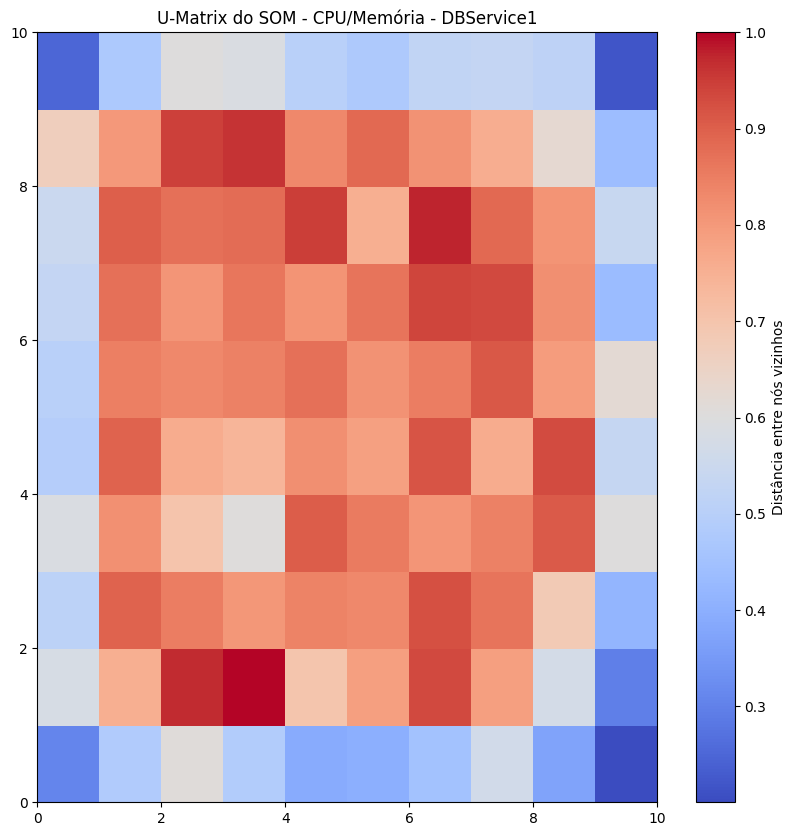

In [ ]:
plt.figure(figsize=(10, 10))

plt.pcolor(som.distance_map().T, cmap='coolwarm')  # U-Matrix
plt.colorbar(label='Distância entre nós vizinhos')
plt.title('U-Matrix do SOM - CPU/Memória - DBService1')
plt.show()

In [ ]:
hit_map = som.activation_response(X_scaled)

plt.figure(figsize=(10, 10))
plt.pcolor(hit_map.T, cmap='Oranges')  # Hitmap
plt.colorbar(label='Número de janelas mapeadas')
plt.title('Hitmap do SOM - CPU/Memória - DBService1')
plt.show()

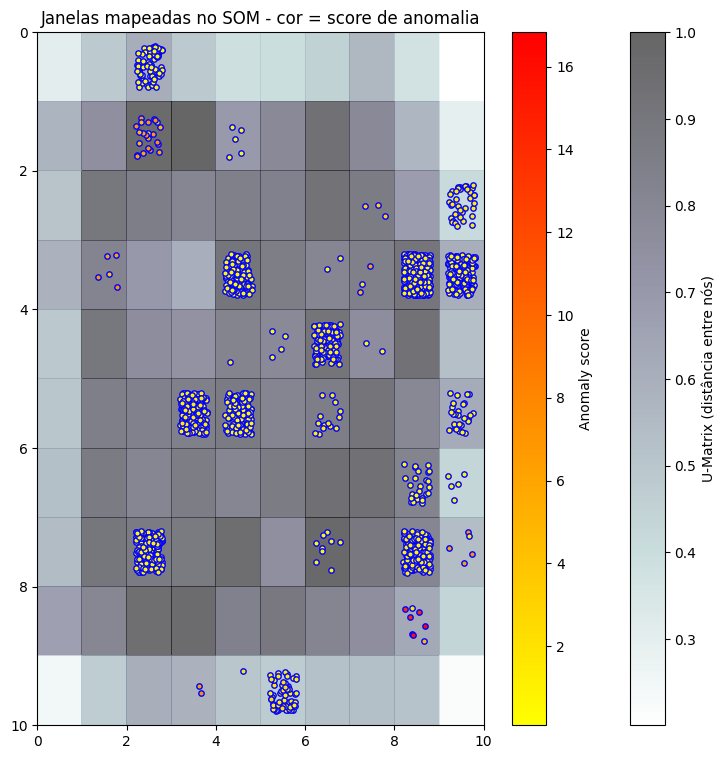

In [50]:
plt.figure(figsize=(9, 9))
plt.pcolor(som.distance_map().T, cmap='bone_r', alpha=0.6)
plt.colorbar(label='U-Matrix (distância entre nós)')

for i, x in enumerate(X_scaled):
    w = som.winner(x)  # posição (linha, coluna) do nó vencedor
    # jitter pra não empilhar pontos exatamente na mesma posição
    jitter_x = w[0] + 0.5 + np.random.uniform(-0.3, 0.3)
    jitter_y = w[1] + 0.5 + np.random.uniform(-0.3, 0.3)
    plt.scatter(
      jitter_x,
      jitter_y,
      c=[scores[i]],
      cmap='autumn_r',
      vmin=scores.min(), 
      vmax=scores.max(),
      s=15, # tamanho dos pontos
      edgecolors='none'
    )

plt.title('Janelas mapeadas no SOM - cor = score de anomalia')
plt.colorbar(label='Anomaly score')
plt.gca().invert_yaxis()
plt.show()